In [2]:
# 3D linear advection: u1_t = - v1 u1_x - lambda1 u_1 + lambda2 p21 u2 + lambda3 p31 u3  
#                      u2_t = - v2 u2_x + lambda1 p12 u_1 - lambda2 u2 + lambda3 p32 u3  
#                      u3_t = - v3 u3_x + lambda1 p13 u_1 + lambda2 p23 u2 + lambda3 u3  
# We need at least one boundary condition as the derivative in x is degree 2
# but since we do not want to define the direction (sign) of a we set two
# PERIODIC BC
# 2 IC: u1(x,0)=a1*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       u2(x,0)=a2*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       u2(x,0)=a3*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       with a3=1-a1-a2
# Spatial discretization: finite differences (upwind or central)
# Time integration: scipy.integrate.odeint

import numpy as np
import scipy
from scipy import integrate
from scipy.linalg import null_space
import matplotlib.pyplot as plt

# initial condition function
def initial_condition(x, A, sigma=500):
    """Dirac delta approximated as a Gaussian with mean zero and variance (sigma^2)/2
    u(x,t) = (1/sqrt(2 pi)) * exp(-x^2 /sigma^2)"""
    u0 = np.outer(A, np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)).flatten()
    return u0


# spatial derivatives
def upwind_derivative(u, dx, v):
    """First-order upwind derivative with periodic BC."""
    if v <= 0:
        return (np.roll(u, -1) - u) / dx       # (u_{i+1} - u_i) / dx
    else:
        return (u - np.roll(u, 1)) / dx         # (u_i - u_{i-1}) / dx


def build_rhs(n, V, Q, N, dx):
    """Return RHS function with periodic BC."""
    def rhs(u, t):
        U = u.reshape((n,N))
        vec = np.zeros((n,N))
        # compute rhs for each state
        # u1_t = - v1 u1_x - lambda1 u_1 + lambda2 p21 u2 + lambda3 p31 u3  
        # u2_t = - v2 u2_x + lambda1 p12 u_1 - lambda2 u2 + lambda3 p32 u3  
        # u3_t = - v3 u3_x + lambda1 p13 u_1 + lambda2 p23 u2 + lambda3 u3 
        
        for i in range(n):
            der = V[i]*upwind_derivative(U[i,:], dx, V[i])
            vec[i,:] += (- der + np.dot(Q[:,i],U))
        return vec.flatten()
    
    return rhs


# solver
def solve_one_state_advection(n, V, Q, A, L, T, N, nsteps, x, dx, t, dt, sigma):
    # Initial condition concatenation between [u10 u20]
    u0 = initial_condition(x, A, sigma)

    # RHS and time grid
    rhs = build_rhs(n, V, Q, N, dx)

    # Integrate ODE system
    def ODE(u, tt):
        return rhs(u, tt)

    u = scipy.integrate.odeint(ODE, u0, t)
    U = u.reshape((nsteps+1,n,N))

    return x, t, U

In [4]:
#set number of states
n = 3

#sigma for IC
sigma = 5

#set velocity
V = np.array([20, -15, 0])

#define lambdas
Lambda = np.array([1.0, 0.5, 0.3])

#define P
PA = np.array([[0.0, 0.2, 0.8], [0.3, 0.0, 0.7], [0.7, 0.3, 0.0]])

#build Q
QA = np.zeros((n,n))
for i in range(n):
    for j in range(0,i):
        QA[i,j] = Lambda[i]*PA[i,j]
    QA[i,i] = -Lambda[i]
    for j in range(i+1,n):
        QA[i,j] = Lambda[i]*PA[i,j]

#set proportions A
A = np.ones(n)/n
print('A =', A)

#set boundary of the domain
L = 40

#set time of simulation
T = 0.5

#number of cells in x grid
N = 8001

#build x grid
x = np.linspace(-L, L, N)

#delta x step
dx = x[1]-x[0] #=(2*L)/N

#obtain dt from the CFL condition
CFL = 0.9 # anything <=1
dt = CFL * dx / max(np.max(np.abs(V)), 1e-12)

nsteps = int(np.ceil(T / dt))
t = np.linspace(0.0, T, nsteps+1)

#time step
dt = T / nsteps

print("dx =", dx, " and dt =", dt)

x, t, UA = solve_one_state_advection(n, V, QA, A, L, T, N, nsteps, x, dx, t, dt, sigma)
totUA = UA[:,0,:] + UA[:,1,:] + UA[:,2,:]

A = [0.33333333 0.33333333 0.33333333]
dx = 0.00999999999999801  and dt = 0.0004496402877697842


In [5]:
#define P
PB = np.array([[0.0, 66/395, 1-(66/395)],
              [79/220, 0.0, 1-(79/220)],
              [158/235, 1-(158/235), 0.0]])

#build Q
QB = np.zeros((n,n))
for i in range(n):
    for j in range(0,i):
        QB[i,j] = Lambda[i]*PB[i,j]
    QB[i,i] = -Lambda[i]
    for j in range(i+1,n):
        QB[i,j] = Lambda[i]*PB[i,j]

print("dx =", dx, " and dt =", dt)

x, t, UB = solve_one_state_advection(n, V, QB, A, L, T, N, nsteps, x, dx, t, dt, sigma)
totUB = UB[:,0,:] + UB[:,1,:] + UB[:,2,:]

dx = 0.00999999999999801  and dt = 0.0004496402877697842


In [6]:
#define P
PC = np.array([[0.0, 0.0, 1.0],
              [61/268, 0.0, 1-(61/268)],
              [108/175, 1-(108/175), 0.0]])

#build Q
QC = np.zeros((n,n))
for i in range(n):
    for j in range(0,i):
        QC[i,j] = Lambda[i]*PC[i,j]
    QC[i,i] = -Lambda[i]
    for j in range(i+1,n):
        QC[i,j] = Lambda[i]*PC[i,j]

print("dx =", dx, " and dt =", dt)

x, t, UC = solve_one_state_advection(n, V, QC, A, L, T, N, nsteps, x, dx, t, dt, sigma)
totUC = UC[:,0,:] + UC[:,1,:] + UC[:,2,:]

dx = 0.00999999999999801  and dt = 0.0004496402877697842


In [7]:
def estimate_max_error():
    #set number of states
    n = 1

    #sigma for IC
    sigma = 5

    #set velocity
    V = np.array([20])

    #define lambdas
    Lambda = np.array([0.0])

    #define P
    P = np.array([[1.0]])

    #build Q
    Q = np.zeros((n,n))
    for i in range(n):
        for j in range(0,i):
            Q[i,j] = Lambda[i]*P[i,j]
        Q[i,i] = -Lambda[i]
        for j in range(i+1,n):
            Q[i,j] = Lambda[i]*P[i,j]

    #set proportions A
    #by computing w s.t. Q^T w = 0 and then P(st)=A
    Qt = Q.T
    W = null_space(Qt)
    #A = W / np.sum(W)
    A = np.ones(n)/n


    #build x grid
    x = np.linspace(-L, L, N)

    #delta x step
    dx = x[1]-x[0] #=(2*L)/N

    #obtain dt from the CFL condition
    CFL = 0.9 # anything <=1
    dt = CFL * dx / max(np.max(np.abs(V)), 1e-12)

    nsteps = int(np.ceil(T / dt))
    t = np.linspace(0.0, T, nsteps+1)

    #time step
    dt = T / nsteps
    print("N =", N)
    print("dx =", dx, " and dt =", dt)

    x, t, U = solve_one_state_advection(n, V, Q, A, L, T, N, nsteps, x, dx, t, dt, sigma)

    # exact solution 
    def exact_solution(x, t, v, a, sigma, initial_condition=initial_condition):
        """Exact solution u(x,t) = u0(x - a t)."""
        x_shift = x - v * t
        return initial_condition(x_shift, a, sigma)
    
    UexactT = np.zeros((nsteps+1,N))
    
    for i in range(nsteps+1):
        UexactT[i,:] = exact_solution(x, t[i], V[0], A[0], sigma)

    
    udiff = np.max(np.abs(U[:,0,:]-UexactT), axis=1)
    
    return udiff

udiff = estimate_max_error()

N = 8001
dx = 0.00999999999999801  and dt = 0.0004496402877697842


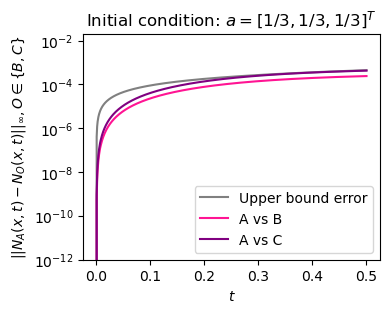

In [8]:
plt.figure(figsize=(4,3))
plt.semilogy(t, udiff, color='grey', label='Upper bound error')
plt.semilogy(t, np.max(np.abs(totUA-totUB),axis=1), color='deeppink', label='A vs B')
plt.semilogy(t, np.max(np.abs(totUA-totUC),axis=1), color='purple', label='A vs C')
plt.xlabel(r"$t$")
plt.ylabel(r"$||N_{A}(x,t)-N_{O}(x,t)||_\infty, O\in\{B,C\}$")
plt.ylim([1e-12,2e-2])
plt.tight_layout()
plt.title(r'Initial condition: $a=[1/3,1/3,1/3]^T$')
plt.legend()
plt.savefig("Figure_S2_equal.png",
            format="png", bbox_inches="tight", dpi=600)
plt.show()